In [67]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix

from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (9, 5)
RANDOM_STATE = 42


In [68]:
DATA_DIR = "..\\ml-32m"
RATINGS_PATH = os.path.join(DATA_DIR, "ratings.csv")
MOVIES_PATH = os.path.join(DATA_DIR, "movies.csv")

# Réduire pour prototyper rapidement ; None = dataset complet.
SAMPLE_SIZE_RATINGS = None

N_COMPONENTS = 50       # dimensions du vecteur "goûts" par utilisateur (sortie de la SVD)
N_CLUSTERS = 20         # nombre de clusters d'utilisateurs (à ajuster, cf. section 4)
MIN_VOTES_IN_CLUSTER = 20  # nb minimum de notes dans un cluster pour qu'un film soit recommandable
TOP_N_RECOMMENDATIONS = 10


In [69]:
ratings = pd.read_csv(RATINGS_PATH)
movies = pd.read_csv(MOVIES_PATH)

if SAMPLE_SIZE_RATINGS is not None and len(ratings) > SAMPLE_SIZE_RATINGS:
    ratings = ratings.sample(n=SAMPLE_SIZE_RATINGS, random_state=RANDOM_STATE)

print(f"Notes : {len(ratings):,} | Utilisateurs : {ratings['userId'].nunique():,} | Films : {ratings['movieId'].nunique():,}")


Notes : 32,000,204 | Utilisateurs : 200,948 | Films : 84,432


In [70]:
# Index contigus pour la matrice creuse
user_ids = ratings["userId"].unique()
movie_ids = ratings["movieId"].unique()

user_to_idx = {u: i for i, u in enumerate(user_ids)}
movie_to_idx = {m: i for i, m in enumerate(movie_ids)}
idx_to_user = {i: u for u, i in user_to_idx.items()}

rows = ratings["userId"].map(user_to_idx).to_numpy()
cols = ratings["movieId"].map(movie_to_idx).to_numpy()
data = ratings["rating"].to_numpy(dtype=np.float32)

user_item_matrix = csr_matrix(
    (data, (rows, cols)), shape=(len(user_ids), len(movie_ids))
)
print(f"Matrice utilisateur x film : {user_item_matrix.shape}, "
      f"densité = {user_item_matrix.nnz / (user_item_matrix.shape[0] * user_item_matrix.shape[1]):.4%}")


Matrice utilisateur x film : (200948, 84432), densité = 0.1886%


In [71]:
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
user_embeddings = svd.fit_transform(user_item_matrix)

print(f"Variance expliquée cumulée ({N_COMPONENTS} composantes) : {svd.explained_variance_ratio_.sum():.2%}")
print(f"Forme des embeddings utilisateurs : {user_embeddings.shape}")


Variance expliquée cumulée (50 composantes) : 35.62%
Forme des embeddings utilisateurs : (200948, 50)


In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
user_embeddings_scaled = scaler.fit_transform(user_embeddings)


k= 5 | inertie=231,389 | silhouette=-0.0026
k=10 | inertie=216,400 | silhouette=-0.0250
k=15 | inertie=205,815 | silhouette=0.0018
k=20 | inertie=197,436 | silhouette=0.0032
k=25 | inertie=191,385 | silhouette=-0.0009
k=30 | inertie=186,045 | silhouette=0.0079


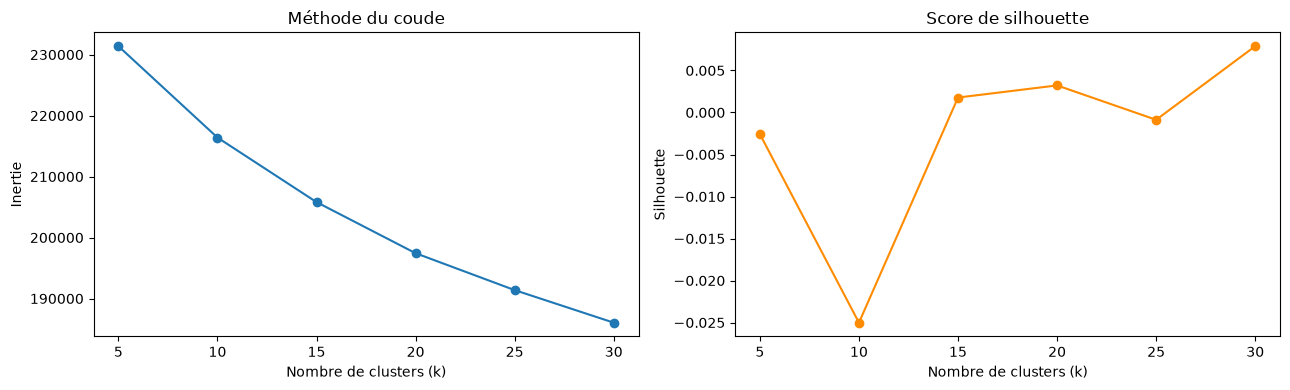

In [73]:
SAMPLE_SIZE_FOR_K_SELECTION = min(5000, user_embeddings_scaled.shape[0])
sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    user_embeddings_scaled.shape[0], size=SAMPLE_SIZE_FOR_K_SELECTION, replace=False
)
sample_embeddings = user_embeddings_scaled[sample_idx]

k_range = range(5, 31, 5)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(sample_embeddings)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(sample_embeddings, labels))
    print(f"k={k:>2} | inertie={km.inertia_:,.0f} | silhouette={silhouettes[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Méthode du coude")
axes[0].set_xlabel("Nombre de clusters (k)")
axes[0].set_ylabel("Inertie")

axes[1].plot(list(k_range), silhouettes, marker="o", color="darkorange")
axes[1].set_title("Score de silhouette")
axes[1].set_xlabel("Nombre de clusters (k)")
axes[1].set_ylabel("Silhouette")

plt.tight_layout()
plt.show()


In [74]:
kmeans = MiniBatchKMeans(
    n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, batch_size=1024, n_init=10
)
user_cluster_labels = kmeans.fit_predict(user_embeddings_scaled)

user_clusters = pd.DataFrame(
    {"userId": [idx_to_user[i] for i in range(len(user_ids))], "cluster": user_cluster_labels}
)

print("Répartition des utilisateurs par cluster :")
user_clusters["cluster"].value_counts().sort_index()


Répartition des utilisateurs par cluster :


cluster
0      4067
1      3448
2     44717
3      5099
4      8566
5     12500
6     11939
7      2506
8      9555
9     10169
10     7507
11     3422
12    13123
13    17253
14     8788
15    15903
16     7476
17     3362
18     3723
19     7825
Name: count, dtype: int64

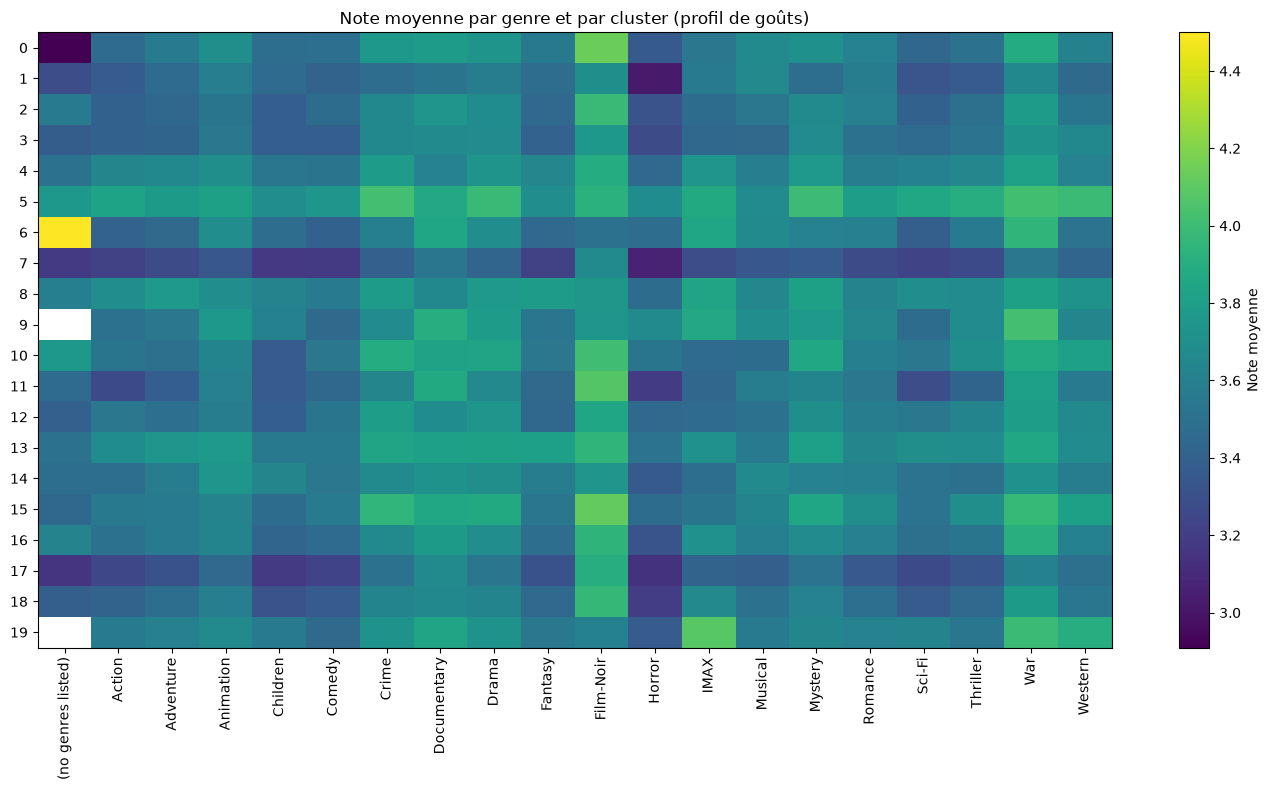

In [75]:
ratings_with_cluster = ratings.merge(user_clusters, on="userId").merge(
    movies[["movieId", "genres"]], on="movieId"
)
ratings_with_cluster["genres"] = ratings_with_cluster["genres"].str.split("|")
exploded = ratings_with_cluster.explode("genres")

cluster_genre_profile = (
    exploded.groupby(["cluster", "genres"])["rating"]
    .mean()
    .unstack("genres")
)

plt.figure(figsize=(14, 8))
plt.imshow(cluster_genre_profile, aspect="auto", cmap="viridis")
plt.colorbar(label="Note moyenne")
plt.xticks(range(len(cluster_genre_profile.columns)), cluster_genre_profile.columns, rotation=90)
plt.yticks(range(len(cluster_genre_profile.index)), cluster_genre_profile.index)
plt.title("Note moyenne par genre et par cluster (profil de goûts)")
plt.tight_layout()
plt.show()


In [76]:
def compute_cluster_top_movies(ratings_with_cluster, min_votes=MIN_VOTES_IN_CLUSTER):
    stats = (
        ratings_with_cluster.groupby(["cluster", "movieId"])["rating"]
        .agg(mean_rating="mean", n_votes="count")
        .reset_index()
    )
    cluster_global_mean = ratings_with_cluster.groupby("cluster")["rating"].mean().rename("cluster_mean")
    stats = stats.merge(cluster_global_mean, on="cluster")

    v, m, R, C = stats["n_votes"], min_votes, stats["mean_rating"], stats["cluster_mean"]
    stats["weighted_rating"] = (v / (v + m)) * R + (m / (v + m)) * C
    return stats


cluster_movie_stats = compute_cluster_top_movies(
    ratings.merge(user_clusters, on="userId")
)
cluster_movie_stats = cluster_movie_stats.merge(movies[["movieId", "title", "genres"]], on="movieId")

# Aperçu : top 10 films du cluster 0
cluster_movie_stats[cluster_movie_stats["cluster"] == 0].sort_values(
    "weighted_rating", ascending=False
).head(10)[["title", "genres", "mean_rating", "n_votes", "weighted_rating"]]


,title,genres,mean_rating,n_votes,weighted_rating
766,"Godfather, The (1972)",Crime|Drama,4.552734,1280,4.537495
817,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Drama|Film-Noir|Romance,4.548101,395,4.500587
1765,Seven Samurai (Shichinin no samurai) (1954),Action|Adventure|Drama,4.526882,372,4.477663
675,Wallace & Gromit: A Close Shave (1995),Animation|Children|Comedy,4.508824,340,4.456233
1059,Lawrence of Arabia (1962),Adventure|Drama|War,4.489700,534,4.456216
1075,"Godfather: Part II, The (1974)",Crime|Drama,4.467358,965,4.448978
49,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,4.461342,1177,4.446319
799,Rear Window (1954),Mystery|Thriller,4.468153,785,4.445644
304,"Shawshank Redemption, The (1994)",Crime|Drama,4.460374,1123,4.444658
2575,American Beauty (1999),Drama|Romance,4.438961,3252,4.433601


In [77]:
def describe_clusters(top_genres=5, top_movies=5, min_votes=50):
    for cluster_id in sorted(user_clusters["cluster"].unique()):
        size = (user_clusters["cluster"] == cluster_id).sum()

        top_g = cluster_genre_profile.loc[cluster_id].sort_values(ascending=False).head(top_genres)

        top_m = (
            cluster_movie_stats[
                (cluster_movie_stats["cluster"] == cluster_id)
                & (cluster_movie_stats["n_votes"] >= min_votes)
            ]
            .sort_values("weighted_rating", ascending=False)
            .head(top_movies)
        )

        print(f"\n=== Cluster {cluster_id} ({size:,} utilisateurs) ===")
        print("Genres les mieux notés :", ", ".join(f"{g} ({v:.2f})" for g, v in top_g.items()))
        print("Films emblématiques :")
        for _, row in top_m.iterrows():
            print(f"  - {row['title']} (note pondérée {row['weighted_rating']:.2f}, {row['n_votes']} votes)")


describe_clusters()



=== Cluster 0 (4,067 utilisateurs) ===
Genres les mieux notés : Film-Noir (4.14), War (3.89), Documentary (3.78), Crime (3.76), Drama (3.73)
Films emblématiques :
  - Godfather, The (1972) (note pondérée 4.54, 1280 votes)
  - Sunset Blvd. (a.k.a. Sunset Boulevard) (1950) (note pondérée 4.50, 395 votes)
  - Seven Samurai (Shichinin no samurai) (1954) (note pondérée 4.48, 372 votes)
  - Wallace & Gromit: A Close Shave (1995) (note pondérée 4.46, 340 votes)
  - Lawrence of Arabia (1962) (note pondérée 4.46, 534 votes)

=== Cluster 1 (3,448 utilisateurs) ===
Genres les mieux notés : Film-Noir (3.70), Musical (3.66), War (3.65), Animation (3.59), Romance (3.58)
Films emblématiques :
  - Shawshank Redemption, The (1994) (note pondérée 4.40, 1896 votes)
  - Pride and Prejudice (1995) (note pondérée 4.36, 282 votes)
  - Princess Bride, The (1987) (note pondérée 4.29, 2310 votes)
  - Life Is Beautiful (La Vita è bella) (1997) (note pondérée 4.24, 1177 votes)
  - Philadelphia Story, The (1940) 

In [78]:
def get_user_genre_set(user_id, min_rating=3.5):
    """Genres des films que l'utilisateur a bien notés (>= min_rating)."""
    user_ratings = ratings[ratings["userId"] == user_id].merge(
        movies[["movieId", "genres"]], on="movieId"
    )
    liked = user_ratings[user_ratings["rating"] >= min_rating]
    genre_set = set()
    for genre_list in liked["genres"].str.split("|"):
        genre_set.update(genre_list)
    return genre_set


def recommend_for_user(user_id, n=TOP_N_RECOMMENDATIONS, genre_penalty=0.6):
    cluster_id = user_clusters.loc[user_clusters["userId"] == user_id, "cluster"]
    if cluster_id.empty:
        raise ValueError(f"Utilisateur {user_id} inconnu.")
    cluster_id = cluster_id.iloc[0]

    already_rated = set(ratings.loc[ratings["userId"] == user_id, "movieId"])
    user_genres = get_user_genre_set(user_id)

    candidates = cluster_movie_stats[
        (cluster_movie_stats["cluster"] == cluster_id)
        & (~cluster_movie_stats["movieId"].isin(already_rated))
    ].copy()

    def has_genre_overlap(genres_str):
        return bool(set(genres_str.split("|")) & user_genres)

    candidates["genre_match"] = candidates["genres"].apply(has_genre_overlap)
    candidates["final_score"] = candidates["weighted_rating"] * np.where(
        candidates["genre_match"], 1.0, genre_penalty
    )

    top = candidates.sort_values("final_score", ascending=False).head(n)
    return top[
        ["movieId", "title", "genres", "weighted_rating", "final_score", "n_votes"]
    ].reset_index(drop=True)


example_user_id = ratings["userId"].iloc[0]
print(f"Recommandations pour l'utilisateur {example_user_id} (cluster {user_clusters.set_index('userId').loc[example_user_id, 'cluster']}) :")
recommend_for_user(example_user_id)


Recommandations pour l'utilisateur 1 (cluster 2) :


,movieId,title,genres,weighted_rating,final_score,n_votes
0,202439,Parasite (2019),Comedy|Drama,4.315758,4.315758,896
1,99764,It's Such a Beautiful Day (2012),Animation|Comedy|Drama|Fantasy|Sci-Fi,4.274082,4.274082,52
2,198185,Twin Peaks (1989),Drama|Mystery,4.259742,4.259742,81
3,904,Rear Window (1954),Mystery|Thriller,4.251384,4.251384,2859
4,930,Notorious (1946),Film-Noir|Romance|Thriller,4.249674,4.249674,796
5,3415,"Mirror, The (Zerkalo) (1975)",Drama,4.244528,4.244528,120
6,5291,Rashomon (Rashômon) (1950),Crime|Drama|Mystery,4.229218,4.229218,474
7,1284,"Big Sleep, The (1946)",Crime|Film-Noir|Mystery,4.227234,4.227234,980
8,5121,Stroszek (1977),Comedy|Drama,4.224770,4.224770,50
9,1212,"Third Man, The (1949)",Film-Noir|Mystery|Thriller,4.216140,4.216140,992


In [79]:
K_EVAL = 10
RATING_THRESHOLD = 4.0
N_EVAL_USERS = 500  # échantillon d'utilisateurs pour accélérer l'évaluation

train_ratings, test_ratings = train_test_split(
    ratings, test_size=0.2, random_state=RANDOM_STATE, stratify=None
)

# Recalcul des stats de cluster sur le train uniquement (évite la fuite de données)
train_with_cluster = train_ratings.merge(user_clusters, on="userId")
cluster_movie_stats_train = compute_cluster_top_movies(train_with_cluster).merge(
    movies[["movieId", "title"]], on="movieId"
)

global_popularity = (
    train_ratings.groupby("movieId")["rating"].agg(mean_rating="mean", n_votes="count")
)
m_global = MIN_VOTES_IN_CLUSTER
C_global = train_ratings["rating"].mean()
global_popularity["weighted_rating"] = (
    global_popularity["n_votes"] / (global_popularity["n_votes"] + m_global)
) * global_popularity["mean_rating"] + (
    m_global / (global_popularity["n_votes"] + m_global)
) * C_global
top_global = global_popularity.sort_values("weighted_rating", ascending=False).head(K_EVAL).index.tolist()


def precision_at_k_cluster(user_id, k=K_EVAL):
    cluster_id = user_clusters.loc[user_clusters["userId"] == user_id, "cluster"]
    if cluster_id.empty:
        return None
    cluster_id = cluster_id.iloc[0]

    rated_in_train = set(train_ratings.loc[train_ratings["userId"] == user_id, "movieId"])
    candidates = cluster_movie_stats_train[
        (cluster_movie_stats_train["cluster"] == cluster_id)
        & (~cluster_movie_stats_train["movieId"].isin(rated_in_train))
    ]
    recommended = set(
        candidates.sort_values("weighted_rating", ascending=False).head(k)["movieId"]
    )

    relevant_test = set(
        test_ratings.loc[
            (test_ratings["userId"] == user_id) & (test_ratings["rating"] >= RATING_THRESHOLD),
            "movieId",
        ]
    )
    if not recommended:
        return None
    return len(recommended & relevant_test) / len(recommended)


def precision_at_k_global(user_id, k=K_EVAL):
    rated_in_train = set(train_ratings.loc[train_ratings["userId"] == user_id, "movieId"])
    recommended = [m for m in top_global if m not in rated_in_train][:k]

    relevant_test = set(
        test_ratings.loc[
            (test_ratings["userId"] == user_id) & (test_ratings["rating"] >= RATING_THRESHOLD),
            "movieId",
        ]
    )
    if not recommended:
        return None
    return len(set(recommended) & relevant_test) / len(recommended)


eval_users = pd.Series(test_ratings["userId"].unique()).sample(
    n=min(N_EVAL_USERS, test_ratings["userId"].nunique()), random_state=RANDOM_STATE
)

cluster_scores = [s for u in eval_users if (s := precision_at_k_cluster(u)) is not None]
global_scores = [s for u in eval_users if (s := precision_at_k_global(u)) is not None]

print(f"Precision@{K_EVAL} — recommandation par cluster : {np.mean(cluster_scores):.4f}")
print(f"Precision@{K_EVAL} — baseline popularité globale : {np.mean(global_scores):.4f}")


Precision@10 — recommandation par cluster : 0.0670
Precision@10 — baseline popularité globale : 0.0260


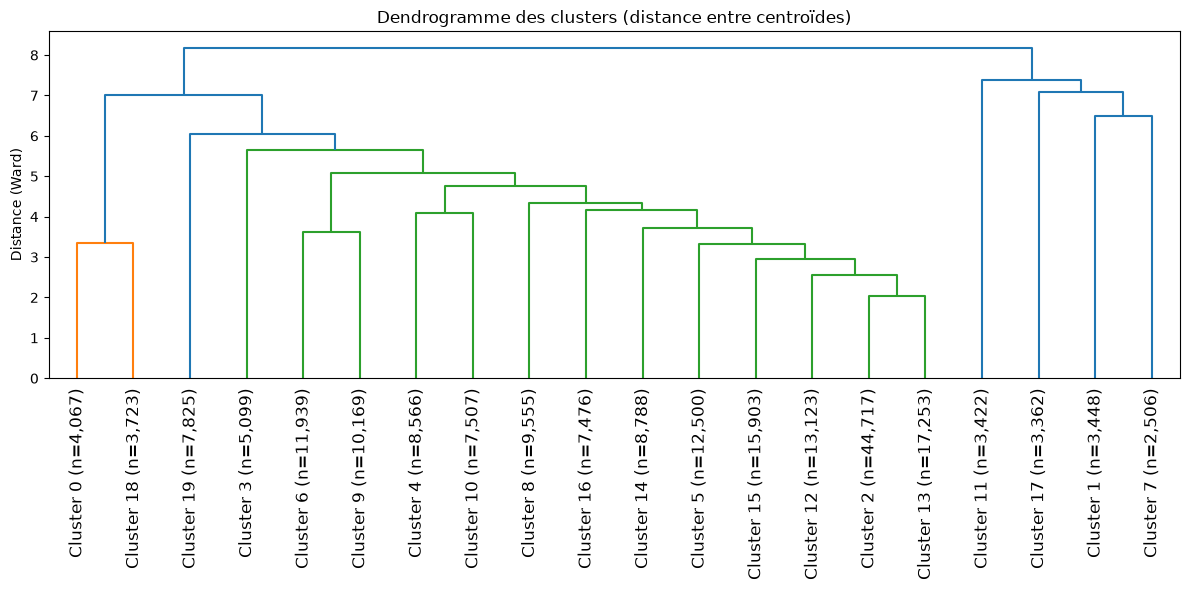

In [80]:
from scipy.cluster.hierarchy import dendrogram, linkage

cluster_sizes = user_clusters["cluster"].value_counts().sort_index()
dendro_labels = [
    f"Cluster {i} (n={cluster_sizes.get(i, 0):,})"
    for i in range(kmeans.cluster_centers_.shape[0])
]

Z = linkage(kmeans.cluster_centers_, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(Z, labels=dendro_labels, leaf_rotation=90)
plt.title("Dendrogramme des clusters (distance entre centroïdes)")
plt.ylabel("Distance (Ward)")
plt.tight_layout()
plt.show()


## 12. Sauvegarde

In [81]:
import pickle

os.makedirs("models", exist_ok=True)
with open("models/clustering_recommender.pkl", "wb") as f:
    pickle.dump(
        {
            "svd": svd,
            "scaler": scaler,
            "kmeans": kmeans,
            "user_to_idx": user_to_idx,
            "user_clusters": user_clusters,
            "cluster_movie_stats": cluster_movie_stats,
        },
        f,
    )

print("Modèle sauvegardé dans models/clustering_recommender.pkl")


Modèle sauvegardé dans models/clustering_recommender.pkl
